In [88]:
import requests

access_token = "409805c741c961de8eb493d5c28b632cc1f22095"
headers = {"Authorization": f"Bearer {access_token}"}

In [76]:
import requests

bounds = "19.19,-99.23,19.50,-98.90"
activity_type = "running"
url = f"https://www.strava.com/api/v3/segments/explore?bounds={bounds}&activity_type={activity_type}"

response = requests.get(url, headers=headers)
segments = response.json()['segments']

KeyError: 'segments'

In [ ]:
import numpy as np

# Strava's /segments/explore endpoint only returns up to 10 segments per request.
# To get more, you need to use the /segments/search endpoint or paginate with other endpoints.
# However, /segments/search is not public. The /segments/explore endpoint does not support a 'per_page' parameter.

# As a workaround, you can try splitting the bounding box into smaller boxes and combine the results.
# Here's an example of splitting the bounding box into a grid and aggregating unique segments:


def split_bounds(sw_lat, sw_lon, ne_lat, ne_lon, n=2):
    """Split bounding box into n x n grid."""
    lats = np.linspace(sw_lat, ne_lat, n+1)
    lons = np.linspace(sw_lon, ne_lon, n+1)
    boxes = []
    for i in range(n):
        for j in range(n):
            box = (
                lats[i], lons[j], lats[i+1], lons[j+1]
            )
            boxes.append(box)
    return boxes

sw_lat, sw_lon = 19.19, -99.23
ne_lat, ne_lon = 19.50, -98.90

boxes = split_bounds(sw_lat, sw_lon, ne_lat, ne_lon, n=10)  # 3x3 grid = 9 boxes (~10 segments per box)

all_segments = {}
for box in boxes:
    bounds_str = f"{box[0]},{box[1]},{box[2]},{box[3]}"
    url = f"https://www.strava.com/api/v3/segments/explore?bounds={bounds_str}&activity_type={activity_type}"
    resp = requests.get(url, headers=headers)
    if resp.status_code == 200:
        for seg in resp.json().get('segments', []):
            all_segments[seg['id']] = seg

segments = list(all_segments.values())
print(f"Total unique segments found: {len(segments)}")

Total unique segments found: 498


In [4]:
segments

[{'id': 6641735,
  'resource_state': 2,
  'name': 'Ignacio Aldama Climb',
  'climb_category': 1,
  'climb_category_desc': '4',
  'avg_grade': 4.0,
  'start_latlng': [19.216857, -99.131298],
  'end_latlng': [19.19988, -99.142123],
  'elev_difference': 101.7,
  'distance': 2528.7,
  'points': 'ihhtBrq`|QlBnBxAjA|@n@jLhHdAf@jA`@f@JlALfEXj@?j@E~B]rAOh@EtABf@Hd@Pd@V`@X~@v@vDnDbBnAhBbAd@RlAd@nAZpATdDTtA?|GElAFf@Df@JfAb@^T\\Xv@z@T`@Pd@\\hAVlADh@CrAYlEYzF',
  'starred': False,
  'elevation_profile': 'https://d3o5xota0a1fcr.cloudfront.net/v6/charts/H4QTFTT3U5AKV5CLVOWTQFSB6NDV6GDMHGCTFAC53BFWDLS7EBCZFDVB72SVCCK63S55FFBUEL7USYXS43NOXUBA',
  'local_legend_enabled': True},
 {'id': 37271983,
  'resource_state': 2,
  'name': 'circuito monte sur 🏃\u200d♂️',
  'climb_category': 0,
  'climb_category_desc': 'NC',
  'avg_grade': 0.0,
  'start_latlng': [19.206535, -99.126926],
  'end_latlng': [19.206525, -99.126903],
  'elev_difference': 16.2,
  'distance': 1322.8,
  'points': 'ygftBhv_|QRBJH@DIf@IPI\\?LD

In [85]:
len(segments)

498

In [14]:
import folium
from polyline import decode

# Create a map centered on the bounding box
m_boxes = folium.Map(location=[(sw_lat + ne_lat) / 2, (sw_lon + ne_lon) / 2], zoom_start=11)

# Plot the 100 boxes
for box in boxes:
    sw = [box[0], box[1]]
    se = [box[0], box[3]]
    ne = [box[2], box[3]]
    nw = [box[2], box[1]]
    folium.PolyLine([sw, se, ne, nw, sw], color='blue', weight=1, opacity=0.5).add_to(m_boxes)

# Track which boxes have at least one segment
box_has_segment = [False] * len(boxes)

# For each segment, find which box it belongs to and plot it
for seg in segments:
    # Use the start_latlng as representative
    lat, lon = seg['start_latlng']
    found = False
    for i, box in enumerate(boxes):
        if box[0] <= lat <= box[2] and box[1] <= lon <= box[3]:
            box_has_segment[i] = True
            found = True
            break
    # Plot the segment polyline if available
    if 'points' in seg and seg['points']:
        try:
            coords = decode(seg['points'])
            folium.PolyLine(coords, color='red', weight=2, opacity=0.7).add_to(m_boxes)
        except Exception:
            pass

# Highlight empty boxes in yellow
for i, has_seg in enumerate(box_has_segment):
    if not has_seg:
        box = boxes[i]
        sw = [box[0], box[1]]
        se = [box[0], box[3]]
        ne = [box[2], box[3]]
        nw = [box[2], box[1]]
        folium.PolyLine([sw, se, ne, nw, sw], color='yellow', weight=3, opacity=0.8).add_to(m_boxes)

m_boxes.save("boxes_and_segments.html")
m_boxes

In [15]:
segments_over_200m = [s for s in segments if s.get('distance', 0) > 200]
print(f"Segments longer than 200m: {len(segments_over_200m)}")
segments_over_200m[:3]  # Show a few examples

Segments longer than 200m: 489


[{'id': 6641735,
  'resource_state': 2,
  'name': 'Ignacio Aldama Climb',
  'climb_category': 1,
  'climb_category_desc': '4',
  'avg_grade': 4.0,
  'start_latlng': [19.216857, -99.131298],
  'end_latlng': [19.19988, -99.142123],
  'elev_difference': 101.7,
  'distance': 2528.7,
  'points': 'ihhtBrq`|QlBnBxAjA|@n@jLhHdAf@jA`@f@JlALfEXj@?j@E~B]rAOh@EtABf@Hd@Pd@V`@X~@v@vDnDbBnAhBbAd@RlAd@nAZpATdDTtA?|GElAFf@Df@JfAb@^T\\Xv@z@T`@Pd@\\hAVlADh@CrAYlEYzF',
  'starred': False,
  'elevation_profile': 'https://d3o5xota0a1fcr.cloudfront.net/v6/charts/H4QTFTT3U5AKV5CLVOWTQFSB6NDV6GDMHGCTFAC53BFWDLS7EBCZFDVB72SVCCK63S55FFBUEL7USYXS43NOXUBA',
  'local_legend_enabled': True},
 {'id': 37271983,
  'resource_state': 2,
  'name': 'circuito monte sur 🏃\u200d♂️',
  'climb_category': 0,
  'climb_category_desc': 'NC',
  'avg_grade': 0.0,
  'start_latlng': [19.206535, -99.126926],
  'end_latlng': [19.206525, -99.126903],
  'elev_difference': 16.2,
  'distance': 1322.8,
  'points': 'ygftBhv_|QRBJH@DIf@IPI\\?LD

In [16]:
import pandas as pd

# Create DataFrame from the filtered segments
segments_over_200m_df = pd.DataFrame(segments_over_200m)

# Define a simple classification function
def classify_segment_type(name):
    name = name.lower()
    if 'pista' in name or 'track' in name:
        return 'track'
    elif 'parque' in name or 'bosque' in name or 'park' in name:
        return 'park'
    else:
        return 'other'

# Create the classification column
segments_over_200m_df['classification'] = segments_over_200m_df['name'].apply(classify_segment_type)

segments_over_200m_df

,id,resource_state,name,climb_category,climb_category_desc,avg_grade,start_latlng,end_latlng,elev_difference,distance,points,starred,elevation_profile,local_legend_enabled,classification
0,6641735,2,Ignacio Aldama Climb,1.0,4,4.0,"[19.216857, -99.131298]","[19.19988, -99.142123]",101.7,2528.7,ihhtBrq`|QlBnBxAjA|@n@jLhHdAf@jA`@f@JlALfEXj@?...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other
1,37271983,2,circuito monte sur 🏃‍♂️,0.0,NC,0.0,"[19.206535, -99.126926]","[19.206525, -99.126903]",16.2,1322.8,ygftBhv_|QRBJH@DIf@IPI\?LDL`@b@@DCDBRUVQ?CDED?...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other
2,37272020,2,5K (4 vueltas) Montesur,0.0,NC,-0.0,"[19.206476, -99.126898]","[19.20653, -99.126951]",21.4,4945.3,mgftBbv_|QHDHJBTCNKRAd@n@p@@HQ\AFUNKNCPGPKLI@M...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other
3,4394350,2,Avenida 5 de Mayo Oriente Climb,0.0,NC,4.5,"[19.210921, -99.092715]","[19.211971, -99.081965]",59.1,1300.4,gcgtBn`y{QD_Eg@mHMoAMi@eAqCe@eAY[[Y_CyAw@w@kCo...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other
4,31155164,2,Romperse el hocico,0.0,NC,-15.3,"[19.200256, -99.068989]","[19.199825, -99.070663]",40.7,266.5,q`etBdlt{QRUDAHB@HCPUp@Wd@KZQ`ABXPd@?TJZJBL@bAX,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,22180320,2,pista del Don /Cerveros running lap,0.0,NC,0.0,"[19.496765, -99.043133]","[19.496725, -99.043135]",7.2,4981.0,w}~uBrjo{Qb@s@DMFw@j@eANkALm@j@w@J[AqADUJ]Xm@H...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,track
485,19912227,2,Malandros 5k /Cerveros lap,0.0,NC,0.0,"[19.493575, -99.045632]","[19.4949, -99.045047]",12.2,4912.2,yi~uBfzo{QIGMQUKi@KoA]_AQc@Sm@a@m@MkA_@_Aa@o@S...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other
486,22075516,2,Aragon speedlap /Lobos bike lap,0.0,NC,-0.0,"[19.493449, -99.045676]","[19.493259, -99.045719]",13.8,4465.2,_i~uBnzo{Q^J|Bx@n@Nr@b@n@Tb@Xl@VZJ\DHALD^VzBb@...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other
487,19912319,2,Pista Río 500mts- Cerveros running lap,0.0,NC,0.0,"[19.493998, -99.050762]","[19.493968, -99.050763]",9.8,514.4,ml~uBhzp{QIHKb@Yl@q@hCOr@IPMx@QXARJPF@L?FKXu@N...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,track


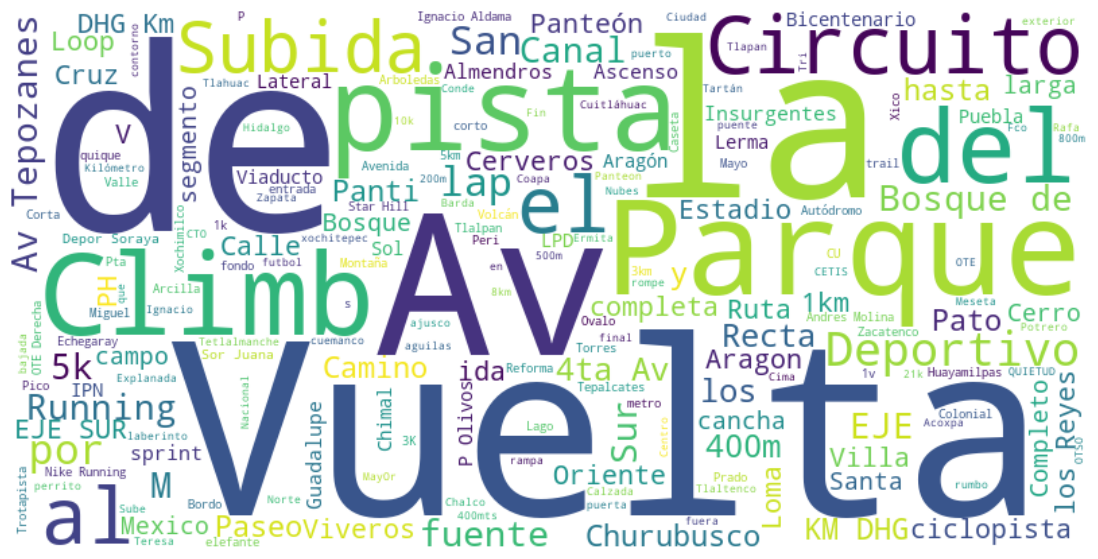

In [19]:
from wordcloud import WordCloud

import matplotlib.pyplot as plt

# Combine all segment names into a single string
text = " ".join(segments_over_200m_df['name'].astype(str))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


**HTTP status code 401 means "Unauthorized"**
It indicates that the request has not been applied because it lacks valid authentication credentials for the target resource.
In other words, your API request is missing a valid access token or the token is invalid/expired.

**HTTP status code 429 means "Too Many Requests"**
This indicates that the user has sent too many requests in a given amount of time ("rate limiting"). If you receive this code from the Strava API, you should slow down your requests and possibly implement a delay or retry mechanism according to the API's rate limit policy.

In [71]:
detailed_segments = []

In [89]:
import time

status_codes = []

for batch_number in range(1, 6):
    batch_indices = ((batch_number-1)*100), (batch_number*100)
    for seg in segments[batch_indices[0]:batch_indices[1]]:
        seg_id = seg['id']
        detail_url = f"https://www.strava.com/api/v3/segments/{seg_id}"
        r = requests.get(detail_url, headers=headers)
        status_codes.append(r.status_code)
        if r.status_code == 200:
            detailed = r.json()
            detailed_segments.append(detailed)
        else:
            print(f"Skipping segment {seg_id} due to status code {r.status_code}")
            continue  # Skip this segment, but continue with the rest
        print(f"Batch {batch_number}")
    if batch_number < 5:
        print(f"Batch {batch_number} done. Sleeping for 20 minutes...")
        time.sleep(20 * 60)


Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1
Batch 1 done. Sleeping for 20 minutes...
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2
Batch 2

In [91]:
detailed_segments_df = pd.DataFrame(detailed_segments)
detailed_segments_df.head()

,id,resource_state,name,activity_type,distance,average_grade,maximum_grade,elevation_high,elevation_low,start_latlng,...,created_at,updated_at,total_elevation_gain,map,effort_count,athlete_count,star_count,athlete_segment_stats,xoms,local_legend
0,6641735,3,Ignacio Aldama Climb,Run,2528.7,4.0,10.6,2650.2,2548.5,"[19.216857, -99.131298]",...,2014-02-11T05:56:11Z,2021-05-15T02:14:40Z,104.8000,"{'id': 's6641735', 'polyline': 'ihhtBrq`|QlBnB...",7,16,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '14:20', 'qom': '15:07', 'overall': '1...","{'athlete_id': 172345549, 'title': 'Edith Mart..."
1,37271983,3,circuito monte sur 🏃‍♂️,Run,1322.8,0.0,16.0,2538.5,2522.3,"[19.206535, -99.126926]",...,2024-07-08T01:34:41Z,2024-07-08T01:34:41Z,22.8655,"{'id': 's37271983', 'polyline': 'ygftBhv_|QRBJ...",683,47,2,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '5:46', 'qom': '6:58', 'overall': '5:4...","{'athlete_id': 150409372, 'title': 'Rodrigo Gu..."
2,37272020,3,5K (4 vueltas) Montesur,Run,4945.3,-0.0,28.3,2548.0,2526.6,"[19.206476, -99.126898]",...,2024-07-08T01:42:59Z,2024-07-08T01:42:59Z,141.2000,"{'id': 's37272020', 'polyline': 'mgftBbv_|QHDH...",149,34,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '21:52', 'qom': '27:33', 'overall': '2...","{'athlete_id': 164638650, 'title': 'Ana Ruiz',..."
3,4394350,3,Avenida 5 de Mayo Oriente Climb,Run,1300.4,4.5,25.3,2629.1,2570.0,"[19.210921, -99.092715]",...,2013-06-12T21:17:23Z,2021-05-15T02:13:19Z,66.5000,"{'id': 's4394350', 'polyline': 'gcgtBn`y{QD_Eg...",269,19,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '5:59', 'qom': '7:21', 'overall': '5:5...","{'athlete_id': 34272958, 'title': 'Enrique Mel..."
4,31155164,3,Romperse el hocico,Run,266.5,-15.3,-3.6,2586.2,2545.5,"[19.200256, -99.068989]",...,2022-03-03T04:09:03Z,2022-03-03T04:09:03Z,0.0000,"{'id': 's31155164', 'polyline': 'q`etBdlt{QRUD...",200,19,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '1:01', 'qom': '1:08', 'overall': '1:0...","{'athlete_id': 115814625, 'title': 'Paty Olagu..."


In [ ]:
#detailed_segments_df.to_csv("detailed_segments.csv", index=False)

In [ ]:
detailed_segments_df

In [99]:
from shapely.geometry import LineString, Point
from shapely.ops import unary_union
import numpy as np
from polyline import decode

# Helper: decode polyline to coordinates
def decode_polyline(polyline_str):
    try:
        return decode(polyline_str)
    except Exception:
        return []

# Create LineString geometries for each segment
def get_linestring(row):
    coords = decode_polyline(row['points'] if 'points' in row else row['map']['polyline'])
    if coords:
        return LineString([(lon, lat) for lat, lon in coords])
    return None

segments_over_200m_df['geometry'] = segments_over_200m_df.apply(get_linestring, axis=1)

# Buffer each segment by 100 meters (approx 0.0009 degrees, rough for Mexico City)
buffer_m = 100
deg_buffer = buffer_m / 111320  # 1 deg ~ 111.32km at equator

segments_over_200m_df['buffer'] = segments_over_200m_df['geometry'].apply(
    lambda g: g.buffer(deg_buffer) if g else None
)

# Find groups of intersecting segments
used = set()
groups = []

for idx, row in segments_over_200m_df.iterrows():
    if idx in used or row['buffer'] is None:
        continue
    group = [idx]
    used.add(idx)
    for idx2, row2 in segments_over_200m_df.iloc[idx+1:].iterrows():
        if idx2 in used or row2['buffer'] is None:
            continue
        if row['buffer'].intersects(row2['buffer']):
            group.append(idx2)
            used.add(idx2)
    groups.append(group)

# For each group, select the longest segment
collapsed_indices = []
for group in groups:
    if len(group) == 1:
        collapsed_indices.append(group[0])
    else:
        # Take the segment with the maximum distance
        max_idx = segments_over_200m_df.loc[group, 'distance'].idxmax()
        collapsed_indices.append(max_idx)

collapsed_segments_df = segments_over_200m_df.loc[collapsed_indices].reset_index(drop=True)
collapsed_segments_df


,id,resource_state,name,climb_category,climb_category_desc,avg_grade,start_latlng,end_latlng,elev_difference,distance,points,starred,elevation_profile,local_legend_enabled,classification,geometry,buffer
0,6641735,2,Ignacio Aldama Climb,1.0,4,4.0,"[19.216857, -99.131298]","[19.19988, -99.142123]",101.7,2528.7,ihhtBrq`|QlBnBxAjA|@n@jLhHdAf@jA`@f@JlALfEXj@?...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.1313 19.21685, -99.13186 19.21...",POLYGON ((-99.13120067567337 19.21568843862946...
1,37272020,2,5K (4 vueltas) Montesur,0.0,NC,-0.0,"[19.206476, -99.126898]","[19.20653, -99.126951]",21.4,4945.3,mgftBbv_|QHDHJBTCNKRAd@n@p@@HQ\AFUNKNCPGPKLI@M...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.1269 19.20647, -99.12693 19.20...",POLYGON ((-99.13085353327645 19.20680932317843...
2,4394350,2,Avenida 5 de Mayo Oriente Climb,0.0,NC,4.5,"[19.210921, -99.092715]","[19.211971, -99.081965]",59.1,1300.4,gcgtBn`y{QD_Eg@mHMoAMi@eAqCe@eAY[[Y_CyAw@w@kCo...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.09272 19.21092, -99.09176 19.2...",POLYGON ((-99.09180524607423 19.21179016363627...
3,31155164,2,Romperse el hocico,0.0,NC,-15.3,"[19.200256, -99.068989]","[19.199825, -99.070663]",40.7,266.5,q`etBdlt{QRUDAHB@HCPUp@Wd@KZQ`ABXPd@?TJZJBL@bAX,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.06899 19.20025, -99.06888 19.2...",POLYGON ((-99.07141232381505 19.20039384697165...
4,26070867,2,La Ruta del Mole 2020,0.0,NC,0.0,"[19.2151, -99.05104]","[19.21507, -99.05102]",88.7,10009.6,k}gtB~{p{QpNoHt@YpAo@^UHK`@A?BdNaAjHOXFtH?nBFr...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.05104 19.2151, -99.04952 19.21...",POLYGON ((-99.05031000774447 19.21218006417006...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,35817261,2,Deportivo Leona Vicario,0.0,NC,-0.1,"[19.487205, -99.083969]","[19.487198, -99.083775]",19.4,3287.7,_b}uBxiw{Qt@RvAf@NGPc@ToAJMHQTsAOMSEc@Sy@WQGQB...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.08397 19.4872, -99.08407 19.48...",POLYGON ((-99.08295871258906 19.48508639096414...
241,39406082,2,1k LPD JS,NaN,NC,0.0,"[19.478616, -99.090179]","[19.47863, -99.090178]",1.4,1026.0,il{uBrpx{QOMQEaBEoASyAa@m@OWAEDK\?FHF~Af@NFRRl...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.09018 19.47861, -99.09011 19.4...",POLYGON ((-99.08925939562627 19.47840179913283...
242,20279985,2,Gamberros 5k Cerveros running lap,0.0,NC,-0.2,"[19.49798, -99.043775]","[19.493215, -99.04575]",16.2,5009.3,ie_vBrno{Qv@NhAZjAf@h@Rb@Vj@Hx@TxAh@v@NzAh@dAX...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,other,"LINESTRING (-99.04378 19.49797, -99.04386 19.4...",POLYGON ((-99.05250895497734 19.47563913262445...
243,22180320,2,pista del Don /Cerveros running lap,0.0,NC,0.0,"[19.496765, -99.043133]","[19.496725, -99.043135]",7.2,4981.0,w}~uBrjo{Qb@s@DMFw@j@eANkALm@j@w@J[AqADUJ]Xm@H...,False,https://d3o5xota0a1fcr.cloudfront.net/v6/chart...,True,track,"LINESTRING (-99.04314 19.49676, -99.04288 19.4...",POLYGON ((-99.04403715126466 19.49674298977038...


In [100]:
# Perform a left join to enrich collapsed_segments_df with columns from detailed_segments_df using 'id'
collapsed_segments_detailed_df = collapsed_segments_df.merge(
    detailed_segments_df,
    on='id',
    how='left',
    suffixes=('', '_detailed')
)

collapsed_segments_detailed_df

,id,resource_state,name,climb_category,climb_category_desc,avg_grade,start_latlng,end_latlng,elev_difference,distance,...,created_at,updated_at,total_elevation_gain,map,effort_count,athlete_count,star_count,athlete_segment_stats,xoms,local_legend
0,6641735,2,Ignacio Aldama Climb,1.0,4,4.0,"[19.216857, -99.131298]","[19.19988, -99.142123]",101.7,2528.7,...,2014-02-11T05:56:11Z,2021-05-15T02:14:40Z,104.8,"{'id': 's6641735', 'polyline': 'ihhtBrq`|QlBnB...",7,16,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '14:20', 'qom': '15:07', 'overall': '1...","{'athlete_id': 172345549, 'title': 'Edith Mart..."
1,37272020,2,5K (4 vueltas) Montesur,0.0,NC,-0.0,"[19.206476, -99.126898]","[19.20653, -99.126951]",21.4,4945.3,...,2024-07-08T01:42:59Z,2024-07-08T01:42:59Z,141.2,"{'id': 's37272020', 'polyline': 'mgftBbv_|QHDH...",149,34,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '21:52', 'qom': '27:33', 'overall': '2...","{'athlete_id': 164638650, 'title': 'Ana Ruiz',..."
2,4394350,2,Avenida 5 de Mayo Oriente Climb,0.0,NC,4.5,"[19.210921, -99.092715]","[19.211971, -99.081965]",59.1,1300.4,...,2013-06-12T21:17:23Z,2021-05-15T02:13:19Z,66.5,"{'id': 's4394350', 'polyline': 'gcgtBn`y{QD_Eg...",269,19,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '5:59', 'qom': '7:21', 'overall': '5:5...","{'athlete_id': 34272958, 'title': 'Enrique Mel..."
3,31155164,2,Romperse el hocico,0.0,NC,-15.3,"[19.200256, -99.068989]","[19.199825, -99.070663]",40.7,266.5,...,2022-03-03T04:09:03Z,2022-03-03T04:09:03Z,0.0,"{'id': 's31155164', 'polyline': 'q`etBdlt{QRUD...",200,19,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '1:01', 'qom': '1:08', 'overall': '1:0...","{'athlete_id': 115814625, 'title': 'Paty Olagu..."
4,26070867,2,La Ruta del Mole 2020,0.0,NC,0.0,"[19.2151, -99.05104]","[19.21507, -99.05102]",88.7,10009.6,...,2020-10-15T14:15:30Z,2021-05-15T02:25:24Z,137.4,"{'id': 's26070867', 'polyline': 'k}gtB~{p{QpNo...",29,25,3,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '33:44', 'qom': '36:18', 'overall': '3...",None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,35817261,2,Deportivo Leona Vicario,0.0,NC,-0.1,"[19.487205, -99.083969]","[19.487198, -99.083775]",19.4,3287.7,...,2023-11-09T05:22:16Z,2023-11-09T05:24:57Z,86.6,"{'id': 's35817261', 'polyline': '_b}uBxiw{Qt@R...",227,20,1,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '14:28', 'qom': '21:40', 'overall': '1...","{'athlete_id': 164106418, 'title': 'melissa mo..."
241,39406082,2,1k LPD JS,NaN,NC,0.0,"[19.478616, -99.090179]","[19.47863, -99.090178]",1.4,1026.0,...,2025-06-15T16:18:11Z,2025-06-15T16:18:11Z,0.0,"{'id': 's39406082', 'polyline': 'il{uBrpx{QOMQ...",11531,148,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '2:20', 'qom': '3:16', 'overall': '2:2...","{'athlete_id': 159745450, 'title': 'Fernando M..."
242,20279985,2,Gamberros 5k Cerveros running lap,0.0,NC,-0.2,"[19.49798, -99.043775]","[19.493215, -99.04575]",16.2,5009.3,...,2019-04-10T17:43:57Z,2021-05-18T08:05:34Z,69.5,"{'id': 's20279985', 'polyline': 'ie_vBrno{Qv@N...",1873,222,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '19:43', 'qom': '21:50', 'overall': '1...","{'athlete_id': 158130802, 'title': 'Juan Leyva..."
243,22180320,2,pista del Don /Cerveros running lap,0.0,NC,0.0,"[19.496765, -99.043133]","[19.496725, -99.043135]",7.2,4981.0,...,2019-10-30T17:08:49Z,2021-05-15T02:24:02Z,32.4,"{'id': 's22180320', 'polyline': 'w}~uBrjo{Qb@s...",62,16,0,"{'pr_elapsed_time': None, 'pr_date': None, 'pr...","{'kom': '22:06', 'qom': '28:21', 'overall': '2...","{'athlete_id': 128123964, 'title': 'Luis Pablo..."


In [108]:
# Get top 245 segments by effort_count
top245 = collapsed_segments_detailed_df.sort_values(by='athlete_count', ascending=False).head(245)

# Normalize athlete_count for color mapping (log scale)
athlete_counts = top245['athlete_count'].fillna(1)
log_counts = np.log10(athlete_counts)
norm = plt.Normalize(log_counts.min(), log_counts.max())
cmap = matplotlib.cm.get_cmap('RdYlGn_r')  # reversed so red = most athletes

# Center map on Mexico City
m_top245 = folium.Map(location=[19.4, -99.14], zoom_start=12, tiles='cartodbpositron')

for _, row in top245.iterrows():
    try:
        polyline_str = row['map.polyline'] if pd.notnull(row.get('map.polyline', None)) else row['points']
        coords = decode(polyline_str)
        count = row['athlete_count'] if pd.notnull(row['athlete_count']) and row['athlete_count'] > 0 else 1
        color = matplotlib.colors.rgb2hex(cmap(norm(np.log10(count))))
        popup_html = f"""
        <b>{row['name']}</b><br>
        <b>Distance:</b> {row['distance']:.1f} m<br>
        <b>Elevation gain:</b> {row.get('total_elevation_gain', 0):.1f} m<br>
        <b>Athlete count:</b> {row['athlete_count']}<br>
        <b>Effort count:</b> {row['effort_count']}<br>
        <b>Average grade:</b> {row['average_grade']:.1f}%<br>
        <b>Max grade:</b> {row.get('maximum_grade', 0):.1f}%<br>
        <b>Classification:</b> {row.get('classification', '')}
        """
        folium.PolyLine(
            coords,
            color=color,
            weight=5,
            opacity=0.8,
            tooltip=f"{row['name']} ({count} athletes)",
            popup=folium.Popup(popup_html, max_width=350)
        ).add_to(m_top245)
    except Exception:
        pass

# Add a legend for the color scale
from branca.element import MacroElement
from jinja2 import Template

min_count = int(athlete_counts.min())
max_count = int(athlete_counts.max())
mid_count = int(10 ** ((np.log10(min_count) + np.log10(max_count)) / 2))

legend_html = f"""
{{% macro html(this, kwargs) %}}
<div style="
    position: fixed; 
    bottom: 40px; left: 40px; width: 260px; height: 70px; 
    background-color: white; 
    border:2px solid grey; z-index:9999; font-size:14px;
    padding: 10px;
">
    <b>Athlete count (log scale)</b><br>
    <div style="display: flex; align-items: center;">
        <span style="margin-right: 8px;">Low</span>
        <div style="flex: 1; height: 18px; background: linear-gradient(to right, #006837, #ffffbf, #a50026);"></div>
        <span style="margin-left: 8px;">High</span>
    </div>
    <div style="display: flex; justify-content: space-between;">
        <span>{min_count}</span>
        <span>{mid_count}</span>
        <span>{max_count}</span>
    </div>
</div>
{{% endmacro %}}
"""

macro = MacroElement()
macro._template = Template(legend_html)
m_top245.get_root().add_child(macro)

m_top245.save("top245_segments_colored.html")
m_top245


/var/folders/jn/vchthz_s5rd_5r6p991p5cpr0000gn/T/ipykernel_29228/598186643.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = matplotlib.cm.get_cmap('RdYlGn_r')  # reversed so red = most athletes


In [ ]:
#collapsed_segments_detailed_df.to_csv("collapsed_segments_detailed.csv", index=False)

## Top pistas, top parques